# Step 1: Initialize SparkSession

In [82]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ETL Project") \
    .getOrCreate()


# Step 2: Load Your Three Data Files

In [84]:
# CSV - US Bike Sales
bike_df = spark.read.option("header", True).csv("dataset/US Bike Sales Data of 100k.csv")

# Convert Excel to CSV beforehand or use pandas to read and convert to Spark DataFrame
import pandas as pd

income_pd = pd.read_excel("dataset/US Personal Income.xlsx")
population_pd = pd.read_excel("dataset/US Resident Population.xlsx")

from pyspark.sql import SQLContext
sqlContext = SQLContext(spark)

income_df = sqlContext.createDataFrame(income_pd)
population_df = sqlContext.createDataFrame(population_pd)

C:\Users\wayne\anaconda3\envs\GBC_Task\lib\site-packages\pyspark\sql\context.py:112: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


# Step 3: Basic Cleaning and Transformation (Handling Nulls, Type Casting)

## 1. Check number of rows (size)

In [87]:
print("Bike sales:", bike_df.count())
print("Income:", income_df.count())
print("Population:", population_df.count())


Bike sales: 100000
Income: 391
Population: 1941


## 2. View schema and data types

In [89]:
bike_df.printSchema()
income_df.printSchema()
population_df.printSchema()


root
 |-- Sale_ID: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- Bike_Model: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- Quantity: string (nullable = true)
 |-- Store_Location: string (nullable = true)
 |-- Salesperson_ID: string (nullable = true)
 |-- Payment_Method: string (nullable = true)
 |-- Customer_Age: string (nullable = true)
 |-- Customer_Gender: string (nullable = true)

root
 |-- Location: string (nullable = true)
 |-- 2021: double (nullable = true)
 |-- 2022: double (nullable = true)
 |-- 2023: double (nullable = true)

root
 |-- Rank: string (nullable = true)
 |-- Geographic Area: string (nullable = true)
 |-- 2020: double (nullable = true)
 |-- 2021: double (nullable = true)
 |-- 2022: double (nullable = true)
 |-- 2023: double (nullable = true)
 |-- 2024: double (nullable = true)



## 3. Check missing/null values in each column

In [91]:
from pyspark.sql.functions import col, sum

# Function to summarize null values per column
def check_missing(df, df_name):
    print(f"\nMissing value summary for {df_name}:")
    df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

check_missing(bike_df, "bike_df")
check_missing(income_df, "income_df")
check_missing(population_df, "population_df")



Missing value summary for bike_df:
+-------+----+-----------+----------+-----+--------+--------------+--------------+--------------+------------+---------------+
|Sale_ID|Date|Customer_ID|Bike_Model|Price|Quantity|Store_Location|Salesperson_ID|Payment_Method|Customer_Age|Customer_Gender|
+-------+----+-----------+----------+-----+--------+--------------+--------------+--------------+------------+---------------+
|      0|   0|          0|         0|    0|       0|             0|             0|             0|           0|              0|
+-------+----+-----------+----------+-----+--------+--------------+--------------+--------------+------------+---------------+


Missing value summary for income_df:
+--------+----+----+----+
|Location|2021|2022|2023|
+--------+----+----+----+
|       0|   0|   0|   0|
+--------+----+----+----+


Missing value summary for population_df:
+----+---------------+----+----+----+----+----+
|Rank|Geographic Area|2020|2021|2022|2023|2024|
+----+---------------

## 4. Preview the first few rows (inspect key columns)

In [93]:
bike_df.show(5)
income_df.show(5)
population_df.show(5)


+-------+----------+-----------+-------------+-------+--------+--------------+--------------+--------------+------------+---------------+
|Sale_ID|      Date|Customer_ID|   Bike_Model|  Price|Quantity|Store_Location|Salesperson_ID|Payment_Method|Customer_Age|Customer_Gender|
+-------+----------+-----------+-------------+-------+--------+--------------+--------------+--------------+------------+---------------+
|      1|11-07-2022|       9390|      Cruiser| 318.32|       1|  Philadelphia|           589|     Apple Pay|          70|         Female|
|      2|03-05-2024|       3374|  Hybrid Bike|3093.47|       4|       Chicago|           390|     Apple Pay|          37|           Male|
|      3|01-09-2022|       2689| Folding Bike|4247.99|       3|   San Antonio|           338|        PayPal|          59|         Female|
|      4|28-09-2022|       3797|Mountain Bike|1722.01|       3|   San Antonio|           352|     Apple Pay|          19|           Male|
|      5|05-01-2021|       1633|  

## 5. bike_df – Add Year Column from Date, Convert Data Types

In [95]:
from pyspark.sql.functions import year, to_date

# Convert 'Date' to DateType and extract 'Year'
bike_df = bike_df.withColumn("Date", to_date(col("Date"), "dd-MM-yyyy"))
bike_df = bike_df.withColumn("Year", year(col("Date")))

# Cast numeric fields to correct types
bike_df = bike_df.withColumn("Price", col("Price").cast("double")) \
                 .withColumn("Quantity", col("Quantity").cast("int")) \
                 .withColumn("Customer_Age", col("Customer_Age").cast("int"))


## 6. Normalize Income Data (2021–2023) and Estimate 2020 & 2024 Using Rolling Forecast

In [110]:
from pyspark.sql.functions import col, expr

# Step 1: Convert wide to long format (2021–2023)
income_long = income_df.selectExpr(
    "Location as State",
    "stack(3, '2021', `2021`, '2022', `2022`, '2023', `2023`) as (Year, Per_Capita_Income)"
).withColumn("Year", col("Year").cast("int")) \
 .withColumn("Per_Capita_Income", col("Per_Capita_Income").cast("double"))

# Step 2: Estimate 2020 using linear extrapolation
income_2020 = income_long.alias("a") \
    .join(income_long.alias("b"),
          (col("a.State") == col("b.State")) &
          (col("a.Year") == 2021) &
          (col("b.Year") == 2022)) \
    .select(
        col("a.State").alias("State"),
        expr("2020").alias("Year"),
        (col("a.Per_Capita_Income") - (col("b.Per_Capita_Income") - col("a.Per_Capita_Income"))).alias("Per_Capita_Income")
    )

# Step 3: Estimate 2024
income_2024 = income_long.alias("b") \
    .join(income_long.alias("c"),
          (col("b.State") == col("c.State")) &
          (col("b.Year") == 2022) &
          (col("c.Year") == 2023)) \
    .select(
        col("b.State").alias("State"),
        expr("2024").alias("Year"),
        (col("c.Per_Capita_Income") + (col("c.Per_Capita_Income") - col("b.Per_Capita_Income"))).alias("Per_Capita_Income")
    )

# Step 4: Combine all
income_extended = income_long.union(income_2020).union(income_2024)

# Step 5: Sort and preview
income_extended.orderBy("State", "Year").show(20, truncate=False)


+-----------------------------------------------------------------------------------------------------------------------------------------------+----+-----------------+
|State                                                                                                                                          |Year|Per_Capita_Income|
+-----------------------------------------------------------------------------------------------------------------------------------------------+----+-----------------+
|1. Per capita personal income was computed using U.S. Census Bureau midyear population estimates for 2021 through 2023, released in March 2024.|2020|NaN              |
|1. Per capita personal income was computed using U.S. Census Bureau midyear population estimates for 2021 through 2023, released in March 2024.|2021|NaN              |
|1. Per capita personal income was computed using U.S. Census Bureau midyear population estimates for 2021 through 2023, released in March 2024.|2022|NaN  

## 7. population_df – Normalize 2020–2024 into Annual_Estimates_Resident_Population

In [112]:
# Convert 2020–2024 population values into long format
population_df = population_df.selectExpr(
    "`Geographic Area` as State",
    "stack(5, '2020', `2020`, '2021', `2021`, '2022', `2022`, '2023', `2023`, '2024', `2024`) as (Year, Annual_Estimates_Resident_Population)"
)

# Cast types
population_df = population_df.withColumn("Year", col("Year").cast("int")) \
                             .withColumn("Annual_Estimates_Resident_Population", col("Annual_Estimates_Resident_Population").cast("double"))


## 8. Preview Results of 5-7

In [119]:
bike_df.show(5)
income_extended.show(5)
population_df.show(5)


+-------+----------+-----------+-------------+-------+--------+--------------+--------------+--------------+------------+---------------+----+
|Sale_ID|      Date|Customer_ID|   Bike_Model|  Price|Quantity|Store_Location|Salesperson_ID|Payment_Method|Customer_Age|Customer_Gender|Year|
+-------+----------+-----------+-------------+-------+--------+--------------+--------------+--------------+------------+---------------+----+
|      1|2022-07-11|       9390|      Cruiser| 318.32|       1|  Philadelphia|           589|     Apple Pay|          70|         Female|2022|
|      2|2024-05-03|       3374|  Hybrid Bike|3093.47|       4|       Chicago|           390|     Apple Pay|          37|           Male|2024|
|      3|2022-09-01|       2689| Folding Bike|4247.99|       3|   San Antonio|           338|        PayPal|          59|         Female|2022|
|      4|2022-09-28|       3797|Mountain Bike|1722.01|       3|   San Antonio|           352|     Apple Pay|          19|           Male|2022|

## 9. Add City_State to income_df

In [121]:
from pyspark.sql.functions import when, col, trim

income_extended = income_extended.withColumn("City_State", 
    when(col("State").contains("Chicago"), "Chicago, IL")
    .when(col("State").contains("Houston"), "Houston, TX")
    .when(col("State").contains("Los Angeles"), "Los Angeles, CA")
    .when(col("State").contains("New York"), "New York, NY")
    .when(col("State").contains("Philadelphia"), "Philadelphia, PA")
    .when(col("State").contains("Phoenix"), "Phoenix, AZ")
    .when(col("State").contains("San Antonio"), "San Antonio, TX")
    .otherwise(None)
)


## 10. Add City_State to population_df 

In [124]:
population_df = population_df.withColumnRenamed("Geographic Area", "State")

population_df = population_df.withColumn("City_State", 
    when(col("State").contains("Chicago"), "Chicago, IL")
    .when(col("State").contains("Houston"), "Houston, TX")
    .when(col("State").contains("Los Angeles"), "Los Angeles, CA")
    .when(col("State").contains("New York"), "New York, NY")
    .when(col("State").contains("Philadelphia"), "Philadelphia, PA")
    .when(col("State").contains("Phoenix"), "Phoenix, AZ")
    .when(col("State").contains("San Antonio"), "San Antonio, TX")
    .otherwise(None)
)


## 11. Add City_State in bike_df

In [127]:
bike_df = bike_df.withColumn("City_State", 
    when(col("Store_Location").contains("Chicago"), "Chicago, IL")
    .when(col("Store_Location").contains("Houston"), "Houston, TX")
    .when(col("Store_Location").contains("Los Angeles"), "Los Angeles, CA")
    .when(col("Store_Location").contains("New York"), "New York, NY")
    .when(col("Store_Location").contains("Philadelphia"), "Philadelphia, PA")
    .when(col("Store_Location").contains("Phoenix"), "Phoenix, AZ")
    .when(col("Store_Location").contains("San Antonio"), "San Antonio, TX")
    .otherwise(None)
)


## Final Check

In [130]:
income_extended.filter(col("City_State").isNotNull()) \
         .select("State", "Year", "Per_Capita_Income", "City_State") \
         .show(10, truncate=False)
population_df.filter(col("City_State").isNotNull()) \
             .select("State", "Year", "Annual_Estimates_Resident_Population", "City_State") \
             .show(10, truncate=False)
bike_df.filter(col("City_State").isNotNull()) \
       .select("Store_Location", "Year", "City_State") \
       .show(10, truncate=False)


+-------------------------------------+----+-----------------+---------------+
|State                                |Year|Per_Capita_Income|City_State     |
+-------------------------------------+----+-----------------+---------------+
|Chicago-Naperville-Elgin, IL-IN-WI   |2021|71206.0          |Chicago, IL    |
|Chicago-Naperville-Elgin, IL-IN-WI   |2022|73317.0          |Chicago, IL    |
|Chicago-Naperville-Elgin, IL-IN-WI   |2023|77429.0          |Chicago, IL    |
|Houston-The Woodlands-Sugar Land, TX |2021|65196.0          |Houston, TX    |
|Houston-The Woodlands-Sugar Land, TX |2022|68808.0          |Houston, TX    |
|Houston-The Woodlands-Sugar Land, TX |2023|72453.0          |Houston, TX    |
|Los Angeles-Long Beach-Anaheim, CA   |2021|75332.0          |Los Angeles, CA|
|Los Angeles-Long Beach-Anaheim, CA   |2022|76760.0          |Los Angeles, CA|
|Los Angeles-Long Beach-Anaheim, CA   |2023|80898.0          |Los Angeles, CA|
|New York-Newark-Jersey City, NY-NJ-PA|2021|83995.0 

# Step 4: Join bike_df, income_df, and population_df on City_State and Year

In [131]:
# Join bike_df with income_df on City_State and Year
bike_with_income = bike_df.join(
    income_extended.select("City_State", "Year", "Per_Capita_Income"),
    on=["City_State", "Year"],
    how="left"
)

# Then join with population_df
final_df = bike_with_income.join(
    population_df.select("City_State", "Year", "Annual_Estimates_Resident_Population"),
    on=["City_State", "Year"],
    how="left"
)


## Preview the Result

In [133]:
final_df.show(10, truncate=False)


+-----------+----+-------+----------+-----------+-------------+-------+--------+--------------+--------------+--------------+------------+---------------+-----------------+------------------------------------+
|City_State |Year|Sale_ID|Date      |Customer_ID|Bike_Model   |Price  |Quantity|Store_Location|Salesperson_ID|Payment_Method|Customer_Age|Customer_Gender|Per_Capita_Income|Annual_Estimates_Resident_Population|
+-----------+----+-------+----------+-----------+-------------+-------+--------+--------------+--------------+--------------+------------+---------------+-----------------+------------------------------------+
|Chicago, IL|2024|2      |2024-05-03|3374       |Hybrid Bike  |3093.47|4       |Chicago       |390           |Apple Pay     |37          |Male           |81541.0          |25469.0                             |
|Chicago, IL|2024|2      |2024-05-03|3374       |Hybrid Bike  |3093.47|4       |Chicago       |390           |Apple Pay     |37          |Male           |81541.

#  Step 5: Export final_df to CSV

In [137]:
final_df.coalesce(1) \
    .write \
    .option("header", True) \
    .mode("overwrite") \
    .csv("output/final_etl_output_single_file")

print("ETL Completed and CSV Exported to 'output/final_etl_output_single_file'")

ETL Completed and CSV Exported to 'output/final_etl_output_single_file'


# Display an ETL Process Flow Diagram

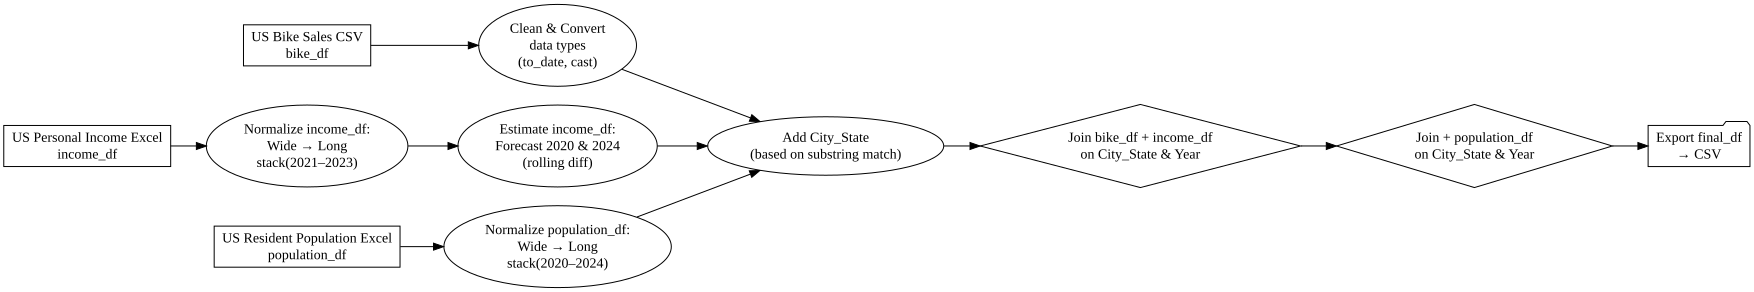

In [138]:
from graphviz import Digraph

dot = Digraph(comment='ETL Process Flow')
dot.attr(rankdir='LR')  # Left to Right layout

# Step 1: Data Sources
dot.node('A', 'US Bike Sales CSV\nbike_df', shape='box')
dot.node('B', 'US Personal Income Excel\nincome_df', shape='box')
dot.node('C', 'US Resident Population Excel\npopulation_df', shape='box')

# Step 2: Preprocessing
dot.node('D1', 'Clean & Convert\ndata types\n(to_date, cast)', shape='ellipse')
dot.node('D2', 'Normalize income_df:\nWide → Long\nstack(2021–2023)', shape='ellipse')
dot.node('D2b', 'Estimate income_df:\nForecast 2020 & 2024\n(rolling diff)', shape='ellipse')
dot.node('D3', 'Normalize population_df:\nWide → Long\nstack(2020–2024)', shape='ellipse')

# Step 3: Location Mapping
dot.node('E', 'Add City_State\n(based on substring match)', shape='ellipse')

# Step 4: Join Tables
dot.node('F1', 'Join bike_df + income_df\non City_State & Year', shape='diamond')
dot.node('F2', 'Join + population_df\non City_State & Year', shape='diamond')

# Step 5: Output
dot.node('G', 'Export final_df\n→ CSV', shape='folder')

# Edges
dot.edge('A', 'D1')
dot.edge('B', 'D2')
dot.edge('D2', 'D2b')
dot.edge('C', 'D3')
dot.edge('D1', 'E')
dot.edge('D2b', 'E')
dot.edge('D3', 'E')
dot.edge('E', 'F1')
dot.edge('F1', 'F2')
dot.edge('F2', 'G')

# Render and display
dot.render('etl_process_flow_diagram_updated', format='png', cleanup=False)
dot